##### Importing a lot of things

In [18]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec  #grid pels subplots
from matplotlib import colors         #colors
from matplotlib.colors import LogNorm   #normalitza a 0-1 en escala logarítmica 
from matplotlib import patches     #figures
from mpl_toolkits.mplot3d import Axes3D   #eixos en 3D
from mpl_toolkits.axes_grid1 import make_axes_locatable  #per canviar la posició dels eixos
from matplotlib.ticker import NullFormatter   #marques(tics) sense etiquetes en els eixos

from astroML.density_estimation import XDGMM
from astroML.plotting.tools import draw_ellipse
from astroML.crossmatch import crossmatch
from astroML.datasets import fetch_sdss_S82standards, fetch_imaging_sample
from astroML.stats import sigmaG
from astroML.utils.decorators import pickle_results
import os
import pickle

import astropy.table     #paquet per manejar taules de dades
from astropy.table import Table, Column, MaskedColumn   #importa taules, columnes i columnes que emmascaren dades invàlides
from astropy.visualization import astropy_mpl_style  #visualització 
from scipy.stats import gaussian_kde  #representation of a kernel-density estimate using Gaussian kernels.
import seaborn as sns  #llibreria per fer gràfics estadístics
import os.path   #per implementar diferents funcions amb pathnames ("dreceres")

from time import time   #mòdul de funcions de time access 
from sklearn import manifold, datasets #manifold: algoritme de dimensionality reduction 
                                       #sklearn (sci-kit learn): llibreria de Python per machine learning
import umap                #Uniform Manifold Approximation and Projection (UMAP) is a dimensionality reduction technique
from sklearn.decomposition import PCA  #Principal component analysis (PCA). Linear dimensionality reduction using Singular Value    
from sklearn.manifold import TSNE #t-SNE [1] is a tool to visualize high-dimensional data
from itertools import product   #producte cartesià

import obtain_data   #per importar dades d'altres fitxers

#from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize=16, usetex=True)

# 1. Preparing the sample (selection of RedClumps)
### 1.1 The GALAH DR3 RC sample
The GALAH DR3 red-clump sample is a selection of RC stars from the GALAH DR3 catalogue. I have put together the possibly interesting portions of the catalogs and cut a sample of red clump (RC) stars using topcat: (teff > 4500 && teff < 5100 && logg > 2.3 && logg < 2.55 && is_redclump_bstep > 0.5). This sample contains 37,417 stars.

In [19]:
import importlib   #package per importar coses a python
importlib.reload(obtain_data)

galah_rc = obtain_data.galah_dr3_rc()   

#### 1.2 Prepare the input arrays for XD

In [20]:
galah_rc.get_ndimspace(feh=True, norm="stdev")

X = galah_rc.X            #(10941, 24)
Xerr = galah_rc.Xerr1         #(10941, 24)
Xcov = np.zeros(Xerr.shape + Xerr.shape[-1:])
Xcov[:, range(Xerr.shape[1]), range(Xerr.shape[1])] = Xerr ** 2    #(10941, 24, 24)

Cal calcular una matriu W (mixture matrix)???  no pq errors d'un element no influeixen en errors d'un altre, en una mateixa estrella

###### Funció gaussiana

In [21]:
def gaussian(x, mu, sigma):
    return np.exp(-(x-mu)**2 / (2*sigma**2))

# 2. Computing XDGMM & BIC

### 2.1 compute_XD, BIC & plots

## Plots elements alpha

### 2.2 (n_components vs BIC)

### 2.3 XD(n_dim,n_components) symmetrical figures

### 2.4 Cluster Probability Arrays
#### Per ara utilitzem 5 gaussianes

In [23]:
@pickle_results('XD_5clusters.pkl')
def compute_XD(n_components, rseed=0, max_iter=100, verbose=True):
    np.random.seed(rseed)
    clf = XDGMM(n_components, max_iter=max_iter, tol=1E-5, verbose=verbose)
    clf.fit(X, Xcov) 
    return clf
# Fit the model on training set
clf = compute_XD(5)

@pickle_results: using precomputed results from 'XD_5clusters.pkl'


In [24]:
# Probabilities for each star to belong to each group
logprob = (clf.logprob_a(X, Xcov))
prob_per_star = np.exp(logprob) / np.sum(np.exp(logprob), axis=1)[:, np.newaxis]  #(10941 estrelles, 5 probs)

Observem que dóna el mateix :)

In [28]:
#Cluster with max probability for each star
import collections
maxprob_per_star = np.argmax(prob_per_star, axis=1)
maxprob_per_star # índex del clúster més probable a pertànyer de cada estrella
maxprob_per_star.shape
N = 0
for i in range (5):
    N += collections.Counter(maxprob_per_star)[i]   # Nombre d'estrelles per cluster
print(N)  # comprovem que la suma de les estrelles de cada cluster dóna el total d'estrelles :)

10941


# 3. Plotting extra dimensions according to probabilities

### Columns to plot

In [30]:
#galah_rc.data.columns.names  #columnes de dades per cada estrella

### 3.1 (R,z)
##### Choosing colour order

El millor és el primer

## z(R)

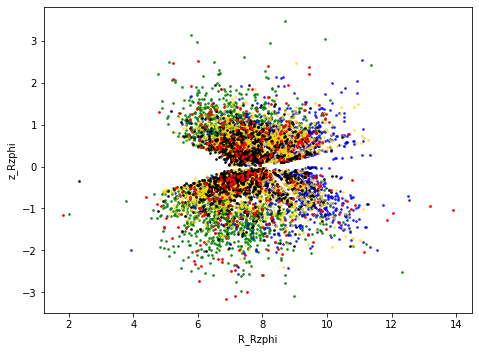

In [31]:
fig = plt.figure(figsize=(7,5))
fig.subplots_adjust(left=0.1, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)
plt.xlabel("R_Rzphi")
plt.ylabel("z_Rzphi")

for ii in [3,4,2,0,1]:      
    plt.scatter(galah_rc.data["R_Rzphi"][maxprob_per_star==ii], galah_rc.data["z_Rzphi"][maxprob_per_star==ii], 
                color=ck[ii], s=3, alpha=1-clf.alpha[ii])

Estrelles blaves més allunyades del centre de la galàxia i més en el seu pla que les verdes, que estan més aprop i arriben més amunt del pla galàctic.

## E (L_z) : Lindblad diagram

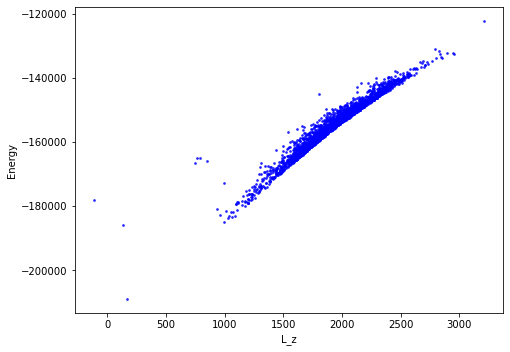

In [32]:
fig = plt.figure(figsize=(7,5))
fig.subplots_adjust(left=0.1, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)
plt.xlabel("L_z")
plt.ylabel("Energy")

for ii in [4]:      
    plt.scatter(galah_rc.data['L_Z'][maxprob_per_star==ii], galah_rc.data['Energy'][maxprob_per_star==ii], 
                color=ck[ii], s=3, alpha=1-clf.alpha[ii])

## Elements majoritaris

n_0:  1273 stars
n_1:  396 stars
n_2:  4057 stars
n_3:  2306 stars
n_4:  2909 stars
21


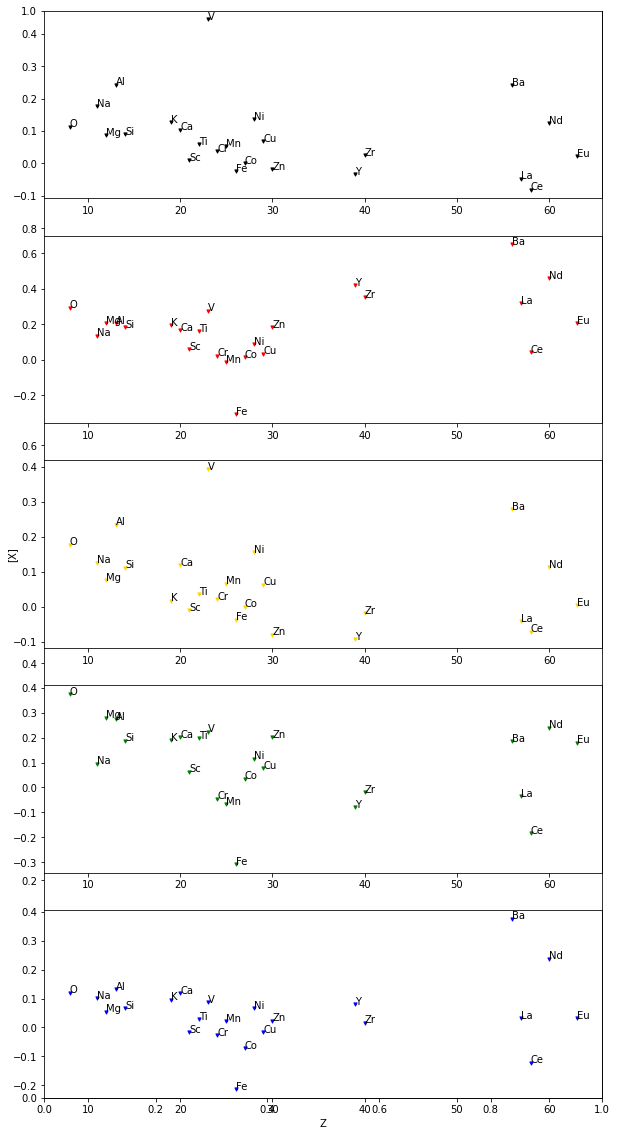

In [45]:
fig = plt.figure(figsize=(10,20))

plt.xlabel("Z")
plt.ylabel("[X]")
X = galah_rc.X[:,:]

Z = {26: "Fe", 8: "O", 11: "Na", 12: "Mg", 13: "Al", 14: "Si", 19: "K", 20: "Ca",
     21: "Sc", 22: "Ti", 23: "V", 24: "Cr", 25: "Mn", 27: "Co", 28: "Ni", 29: "Cu",
     30: "Zn", 39: "Y",  40: "Zr", 56: "Ba", 57: "La", 58: "Ce", 60: "Nd", 63: "Eu"}

Z = [26,8,11,12,13,14,19,20,21,22,23,24,25,27,28,29,30,39,40,56,57,58,60,63]
Z_labels = ["Fe","O","Na","Mg","Al","Si","K","Ca","Sc","Ti","V","Cr","Mn","Co","Ni","Cu","Zn","Y","Zr","Ba","La","Ce","Nd","Eu"]

for i in range (5):  # pels 5 clusters
    n = collections.Counter(maxprob_per_star)[i] # n stars in each cluster
    print('n_'+str(i)+': ', n, 'stars')

# Mean [X] for each cluster
X_mean0 = np.sum(X[maxprob_per_star==0], axis=0) / 1273   #suma en vertical
X_mean1 = np.sum(X[maxprob_per_star==1], axis=0) / 396   
X_mean2 = np.sum(X[maxprob_per_star==2], axis=0) / 4057   
X_mean3 = np.sum(X[maxprob_per_star==3], axis=0) / 2306  
X_mean4 = np.sum(X[maxprob_per_star==4], axis=0) / 2909 

print(np.argmax(X_mean0))

ax1 = fig.add_subplot(5,1,1)
ax2 = fig.add_subplot(5,1,2)
ax3 = fig.add_subplot(5,1,3)
ax4 = fig.add_subplot(5,1,4)
ax5 = fig.add_subplot(5,1,5)

ax1.scatter(Z, X_mean0, color=ck[0], marker="v", s=10, alpha=1)    
ax2.scatter(Z, X_mean1, color=ck[1], marker="v", s=10, alpha=1)
ax3.scatter(Z, X_mean2, color=ck[2], marker="v", s=10, alpha=1)
ax4.scatter(Z, X_mean3, color=ck[3], marker="v", s=10, alpha=1)
ax5.scatter(Z, X_mean4, color=ck[4], marker="v", s=10, alpha=1)

for i, label in enumerate(Z_labels):
    ax1.annotate(label, (Z[i], X_mean0[i]))
    ax2.annotate(label, (Z[i], X_mean1[i]))
    ax3.annotate(label, (Z[i], X_mean2[i]))
    ax4.annotate(label, (Z[i], X_mean3[i]))
    ax5.annotate(label, (Z[i], X_mean4[i]))

    
plt.savefig("../im/final_im/mean_abundances.png", dpi=200)

## v_perp(v_orbital) : TOOMRE diagram

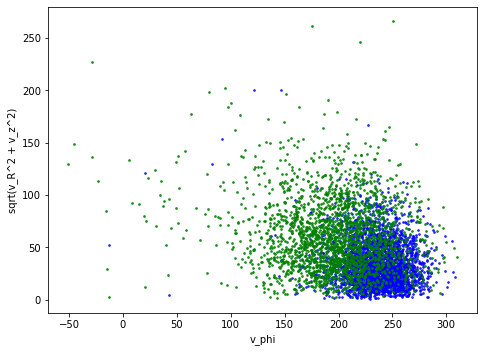

In [40]:
fig = plt.figure(figsize=(7,5))
fig.subplots_adjust(left=0.1, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)
plt.xlabel("v_phi")
plt.ylabel("sqrt(v_R^2 + v_z^2)")
for ii in [4,3]:
    X = galah_rc.data['vT_Rzphi'][maxprob_per_star==ii]
    Y = np.sqrt(((galah_rc.data['vR_Rzphi'][maxprob_per_star==ii])**2) + ((galah_rc.data['vz_Rzphi'][maxprob_per_star==ii])**2))

    plt.scatter(X,Y,    color=ck[ii], s=3, alpha=1-clf.alpha[ii])
plt.savefig("../im/final_im/toomre.png", dpi=200)

## z_max (ecc)

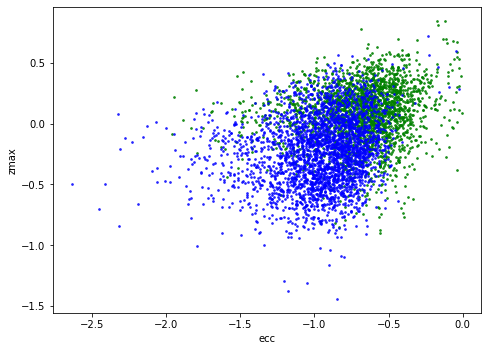

In [41]:
fig = plt.figure(figsize=(7, 5))
fig.subplots_adjust(left=0.1, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)

plt.xlabel("ecc")
plt.ylabel("zmax")

for ii in [3,4]:
    plt.scatter(np.log10(galah_rc.data["ecc"][maxprob_per_star==ii]), np.log10(galah_rc.data["zmax"][maxprob_per_star==ii]), 
                color=ck[ii], s=3, alpha=1-clf.alpha[ii])
    #blau: excentricitats més baixes
    #verd: excentricitats més altes

Més excentricitat comporta normalment z_max més alta sobre el pla de la galàxia.

S'observen diferències sobretot en els colors verd (ecc més altes) i blau (ecc baixes)

# 3D plot

In [ ]:
from mpl_toolkits import mplot3d
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection='3d')
plt.xlabel("X_XYZ")
plt.ylabel("Y_XYZ")
'''ck = ["k", "r", "gold", "g", "b",
          "orange", "cyan", "lime", "m", "yellow",
          "indianred", "hotpink", "peru", "cornflowerblue", "olivedrab",
          "grey", "turquoise", "lightpink", "navy", "khaki",
          "darkgreen", "crimson", "deepskyblue", "sandybrown", "limegreen",
          "deeppink", "dodgerblue", "rebeccapurple", "teal", "magenta"]''' #per recordar els colors
for ii in [0,1,2,3,4]:
    ax.scatter3D(galah_rc.data["X_XYZ"][maxprob_per_star==ii],
             galah_rc.data["Y_XYZ"][maxprob_per_star==ii],
             galah_rc.data["Z_XYZ"][maxprob_per_star==ii],
             color=ck[ii], s=3, alpha=1-clf.alpha[ii])
    

# Cinematic plots

In [ ]:
# Fem un plot per cada cluster
# Corner no deixa fer els plots amb diferents colors, cal superposar-los. com?
import corner
for ii in [0,1,2,3,4]:
    R_phi_z = np.array([galah_rc.data["R_Rzphi"][maxprob_per_star==ii],
                                     galah_rc.data["phi_Rzphi"][maxprob_per_star==ii],
                                     galah_rc.data["z_Rzphi"][maxprob_per_star==ii]]).T
    figure = corner.corner(R_phi_z, 
                            weights=None,
                            bins=30, 
                            range=[[4,12],[-.5,0.5],[-2,2]],
                            labels=[r"$R_{\rm Gal}$ [kpc]", r"$\varphi$", r"$Z_{\rm Gal}$ [kpc]"],
                            quantiles=[0.16, 0.5, 0.84],
                            plot_datapoints=False,
                            show_titles=False,
                            label_kwargs={"fontsize": 20})
    plt.savefig("../im/(R,phi,z)cluster"+str(ii+1)+".png")

In [ ]:
# Intentem fer els plots de dalt superposats i cadascun amb un color diferent
"""Demo to overlay multiple corners on top of each other"""
import corner
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np


CORNER_KWARGS = dict( 
                    #quantiles=[0.16, 0.5, 0.84],    #(són línies verticals discontínues de separació)
                    #plot_datapoints=True,
                    #range=[[-2.5,1],[-1.5,1]],   #rang dels eixos, no canvia????
                    show_titles=False,
                    label_kwargs={"fontsize": 20},    
                    smooth=0.9,
                    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.)),
                    plot_density=False,
                    fill_contours=True,
                    max_n_ticks=4)


def overlaid_corner(samples_list, sample_labels, file):
    """Plots multiple corners on top of each other"""
    # get some constants
    n = len(samples_list)  # nombre de clusters
    _, ndim = samples_list[0].shape  # dimensions a representar (R,phi,z)
    max_len = max([len(s) for s in samples_list])
    ck = ["k", "r", "gold", "g", "b",   # colors dels clusters
          "orange", "cyan", "lime", "m", "yellow",
          "indianred", "hotpink", "peru", "cornflowerblue", "olivedrab",
          "grey", "turquoise", "lightpink", "navy", "khaki",
          "darkgreen", "crimson", "deepskyblue", "sandybrown", "limegreen",
          "deeppink", "dodgerblue", "rebeccapurple", "teal", "magenta"]

    plot_range = []
    for dim in range(ndim):  # cada dimensió
        plot_range.append([min([min(samples_list[i].T[dim]) for i in range(n)]),
                           max([max(samples_list[i].T[dim]) for i in range(n)])])

    CORNER_KWARGS.update(range=plot_range)
    
   
    #  samples_list = [ [dims_cluster1],  [dims_cluster2], [dims_cluster3] ]
    
    fig = corner.corner(samples_list[0],   # primer cluster
                        color=ck[0],
                        **CORNER_KWARGS)

  
    for idx in range(1, n):       # pels altres clusters
        fig = corner.corner(samples_list[idx],
                            fig=fig,
                            weights=get_normalisation_weight(len(samples_list[idx]), max_len),
                            labels=sample_labels,
                            color=ck[idx],
                            **CORNER_KWARGS)
        
    legend_labels = ["Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4", "Cluster 5",
                     "Cluster 6", "Cluster 7", "Cluster 8", "Cluster 9", "Cluster 10"]
        
    plt.legend(handles=[mlines.Line2D([], [], color=ck[i], label=legend_labels[i]) for i in range(n)],
                        fontsize=10, 
                        frameon=False,
                        bbox_to_anchor=(1, ndim),
                        loc="upper right")
        
    plt.savefig(file)
    plt.close()


'''def get_normalisation_weight(len_current_samples, len_of_longest_samples):
    return np.ones(len_current_samples) * (len_of_longest_samples / len_current_samples)


def main():
    ndim, nsamples = 3, 10000
    samples = np.random.randn(ndim * nsamples).reshape([nsamples, ndim])

    overlaid_corner(
        [samples * 3, samples * 2, samples],
        ["samples x 3", "samples x 2", "samples"],
        file
    )


if __name__ == "__main__":
    main()'''



In [ ]:
# R vs phi vs z:
R_phi_z = []  # construim una llista de matrius: 1a matriu es R,phi,z(columnes) pel primer cluster, 2a ...
for ii in [0,1,2,3,4]:
    R_phi_z.append(np.array([galah_rc.data["R_Rzphi"][maxprob_per_star==ii],
                             galah_rc.data["phi_Rzphi"][maxprob_per_star==ii],
                             galah_rc.data["z_Rzphi"][maxprob_per_star==ii]]).T)
R_phi_z_labels = [r"$R_{\rm Gal}$ [kpc]", r"$\varphi$", r"$Z_{\rm Gal}$ [kpc]"]



# ecc vs zmax:
ecc_zmax = []
for ii in [0,1,2,3,4]:
    ecc_zmax.append(np.array([np.log10(galah_rc.data["ecc"][maxprob_per_star==ii]),
                             np.log10(galah_rc.data["zmax"][maxprob_per_star==ii])]).T)    
ecc_zmax_labels = [r"e",'$z_{max}$']


  
    
# Execute functions & saving
overlaid_corner(R_phi_z, R_phi_z_labels,"../im/(R,phi,z)_5clusters.png")
overlaid_corner(ecc_zmax, ecc_zmax_labels,"../im/(ecc,zmax)_5clusters.png")